In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings
warnings.filterwarnings('ignore')

# Set style for professional plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")
sns.set_context("notebook", font_scale=1.2)

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [4]:
# Load the sentiment analysis results by combining Task 1 and Task 2 outputs
from pathlib import Path

project_root = Path.cwd()

def find_existing_file(candidates):
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None

base_candidates = [
    project_root / 'notebooks' / 'data' / 'processed' / 'ethiopian_bank_reviews_clean.csv',
    project_root / 'data' / 'processed' / 'ethiopian_bank_reviews_clean.csv',
    project_root / 'data' / 'raw' / 'ethiopian_bank_reviews_clean.csv',
]
sentiment_candidates = [
    project_root / 'data' / 'processed' / 'fintech_sentiment_analysis_results.csv',
    project_root / 'notebooks' / 'data' / 'processed' / 'fintech_sentiment_analysis_results.csv',
]

base_path = find_existing_file(base_candidates)
if base_path is None:
    raise FileNotFoundError(f'Base cleaned CSV not found. Checked: {base_candidates}')

sentiment_path = find_existing_file(sentiment_candidates)
if sentiment_path is None:
    raise FileNotFoundError(f'Sentiment CSV not found. Checked: {sentiment_candidates}')

base_df = pd.read_csv(base_path)
sentiment_df = pd.read_csv(sentiment_path)

base_df['_review_key'] = base_df['review'].astype(str).str.replace(r'\s+', ' ', regex=True).str.strip().str.lower()
sentiment_df['_review_key'] = sentiment_df['review_text'].astype(str).str.replace(r'\s+', ' ', regex=True).str.strip().str.lower()

sentiment_lookup = (
    sentiment_df.drop_duplicates(subset=['_review_key'], keep='first')
    .set_index('_review_key')[['sentiment_label', 'sentiment_score', 'identified_theme']]
)

combined_df = base_df.join(sentiment_lookup, on='_review_key')
combined_df = combined_df.drop(columns=['_review_key'])

unmatched = int(combined_df['sentiment_label'].isna().sum())
if unmatched:
    print(f'⚠️ {unmatched} reviews did not match Task 2 output and will use default sentiment values.')
    combined_df['sentiment_label'] = combined_df['sentiment_label'].fillna('neutral')
    combined_df['sentiment_score'] = combined_df['sentiment_score'].fillna(0.0)
    combined_df['identified_theme'] = combined_df['identified_theme'].fillna('Other')

combined_df['sentiment_label'] = combined_df['sentiment_label'].astype(str).str.upper()
combined_df['review_text'] = combined_df['review']
combined_df['sentiment_score'] = pd.to_numeric(combined_df['sentiment_score'], errors='coerce').fillna(0.0)

df = combined_df

Path('plots').mkdir(parents=True, exist_ok=True)

print('Loaded base data from:', base_path)
print('Loaded sentiment data from:', sentiment_path)
print(f'📂 Loaded {len(df)} reviews')
print(f'📊 Columns: {list(df.columns)}')
print(f"\n🏦 Banks in dataset:")
print(df['bank'].value_counts())

⚠️ 1 reviews did not match Task 2 output and will use default sentiment values.
Loaded base data from: c:\Users\HP EliteBook\Desktop\KAIM\fintech-review-analytics\notebooks\data\processed\ethiopian_bank_reviews_clean.csv
Loaded sentiment data from: c:\Users\HP EliteBook\Desktop\KAIM\fintech-review-analytics\notebooks\data\processed\fintech_sentiment_analysis_results.csv
📂 Loaded 1134 reviews
📊 Columns: ['review', 'rating', 'date', 'bank', 'source', 'sentiment_label', 'sentiment_score', 'identified_theme', 'review_text']

🏦 Banks in dataset:
bank
Dashen Bank                    382
Bank of Abyssinia              378
Commercial Bank of Ethiopia    374
Name: count, dtype: int64


In [5]:
# Calculate key metrics
print("=" * 60)
print("📊 KEY METRICS SUMMARY")
print("=" * 60)

summary_data = []

for bank in df['bank'].unique():
    bank_df = df[df['bank'] == bank]
    avg_rating = bank_df['rating'].mean()
    positive_pct = (bank_df['sentiment_label'] == 'POSITIVE').mean() * 100
    negative_pct = (bank_df['sentiment_label'] == 'NEGATIVE').mean() * 100
    neutral_pct = (bank_df['sentiment_label'] == 'NEUTRAL').mean() * 100
    
    summary_data.append({
        'Bank': bank,
        'Avg Rating': f"{avg_rating:.2f} ⭐",
        'Positive %': f"{positive_pct:.1f}%",
        'Negative %': f"{negative_pct:.1f}%",
        'Neutral %': f"{neutral_pct:.1f}%",
        'Total Reviews': len(bank_df)
    })
    
    print(f"\n{bank}:")
    print(f"  Average Rating: {avg_rating:.2f} ⭐")
    print(f"  Positive Sentiment: {positive_pct:.1f}%")
    print(f"  Negative Sentiment: {negative_pct:.1f}%")
    print(f"  Neutral Sentiment: {neutral_pct:.1f}%")
    print(f"  Total Reviews: {len(bank_df)}")

summary_df = pd.DataFrame(summary_data)
print("\n" + "=" * 60)
print("📋 SUMMARY TABLE")
print(summary_df.to_string(index=False))

📊 KEY METRICS SUMMARY

Commercial Bank of Ethiopia:
  Average Rating: 3.92 ⭐
  Positive Sentiment: 57.0%
  Negative Sentiment: 43.0%
  Neutral Sentiment: 0.0%
  Total Reviews: 374

Bank of Abyssinia:
  Average Rating: 3.23 ⭐
  Positive Sentiment: 40.2%
  Negative Sentiment: 59.8%
  Neutral Sentiment: 0.0%
  Total Reviews: 378

Dashen Bank:
  Average Rating: 3.68 ⭐
  Positive Sentiment: 54.5%
  Negative Sentiment: 45.3%
  Neutral Sentiment: 0.3%
  Total Reviews: 382

📋 SUMMARY TABLE
                       Bank Avg Rating Positive % Negative % Neutral %  Total Reviews
Commercial Bank of Ethiopia     3.92 ⭐      57.0%      43.0%      0.0%            374
          Bank of Abyssinia     3.23 ⭐      40.2%      59.8%      0.0%            378
                Dashen Bank     3.68 ⭐      54.5%      45.3%      0.3%            382


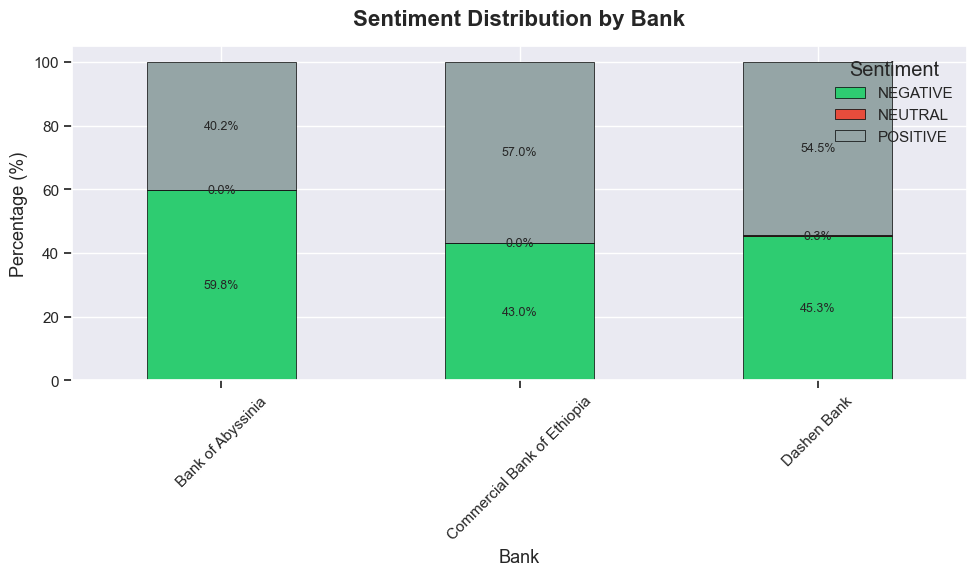

✅ Saved: plots/sentiment_distribution.png


In [6]:
# Sentiment distribution by bank
fig, ax = plt.subplots(figsize=(10, 6))

# Calculate sentiment proportions
sentiment_by_bank = pd.crosstab(df['bank'], df['sentiment_label'], normalize='index') * 100

# Plot stacked bar chart
sentiment_by_bank.plot(kind='bar', stacked=True, ax=ax, 
                       color=['#2ecc71', '#e74c3c', '#95a5a6'],
                       edgecolor='black', linewidth=0.5)

ax.set_title('Sentiment Distribution by Bank', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Bank', fontsize=13)
ax.set_ylabel('Percentage (%)', fontsize=13)
ax.legend(title='Sentiment', loc='upper right', fontsize=11)
ax.tick_params(axis='x', rotation=45, labelsize=11)
ax.tick_params(axis='y', labelsize=11)

# Add value labels on bars
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', label_type='center', fontsize=9)

plt.tight_layout()
plt.savefig('plots/sentiment_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: plots/sentiment_distribution.png")

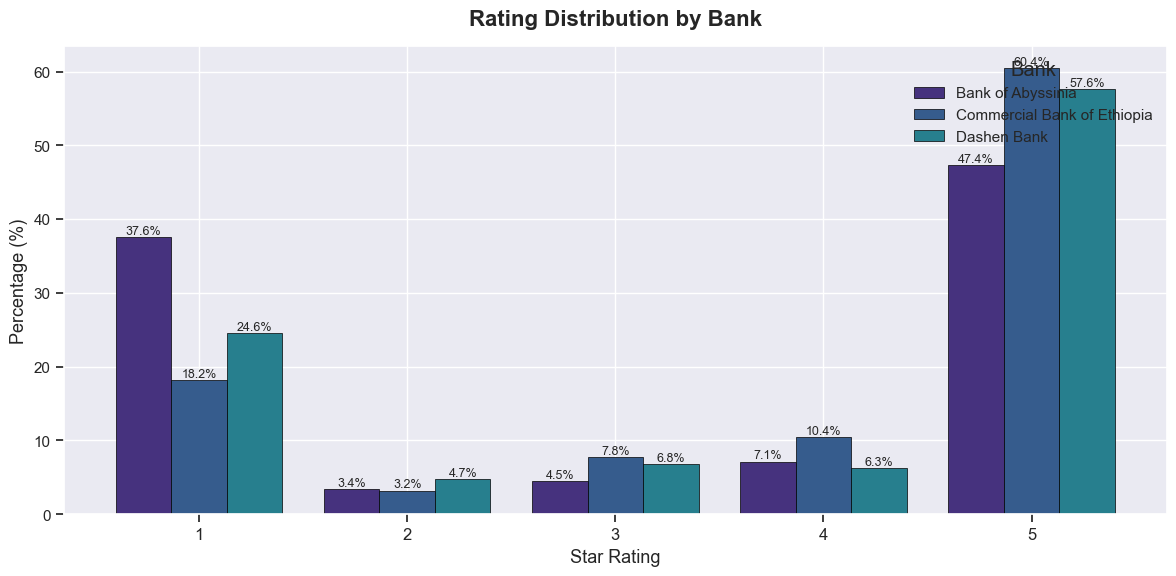

✅ Saved: plots/rating_distribution.png


In [7]:
# Rating distribution by bank
fig, ax = plt.subplots(figsize=(12, 6))

# Calculate rating distribution
rating_dist = pd.crosstab(df['bank'], df['rating'], normalize='index') * 100

# Plot grouped bar chart
rating_dist.T.plot(kind='bar', ax=ax, width=0.8, edgecolor='black', linewidth=0.5)

ax.set_title('Rating Distribution by Bank', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Star Rating', fontsize=13)
ax.set_ylabel('Percentage (%)', fontsize=13)
ax.legend(title='Bank', loc='upper right', fontsize=11)
ax.tick_params(axis='x', rotation=0, labelsize=12)
ax.tick_params(axis='y', labelsize=11)

# Add value labels
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', fontsize=9)

plt.tight_layout()
plt.savefig('plots/rating_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: plots/rating_distribution.png")

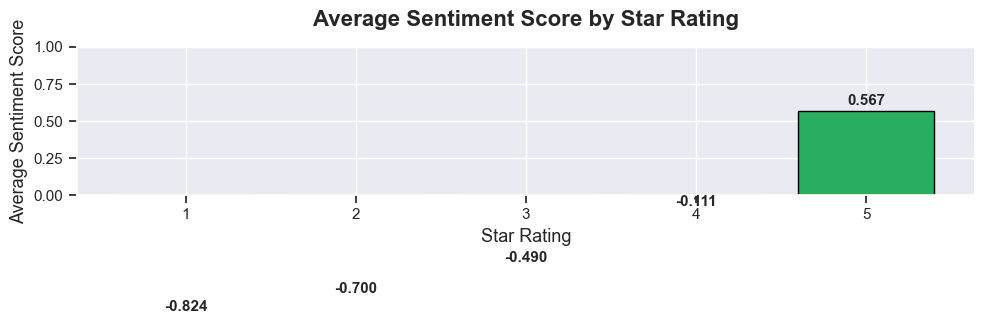

✅ Saved: plots/sentiment_by_rating.png


In [8]:
# Sentiment score vs rating
fig, ax = plt.subplots(figsize=(10, 6))

# Calculate average sentiment score by rating
sentiment_by_rating = df.groupby('rating')['sentiment_score'].mean()

# Create bar chart
colors = ['#e74c3c', '#e67e22', '#f39c12', '#2ecc71', '#27ae60']
bars = ax.bar(sentiment_by_rating.index, sentiment_by_rating.values, 
              color=colors, edgecolor='black', linewidth=1)

ax.set_title('Average Sentiment Score by Star Rating', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Star Rating', fontsize=13)
ax.set_ylabel('Average Sentiment Score', fontsize=13)
ax.set_ylim(0, 1)
ax.tick_params(labelsize=11)

# Add value labels on bars
for bar, value in zip(bars, sentiment_by_rating.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{value:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/sentiment_by_rating.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: plots/sentiment_by_rating.png")

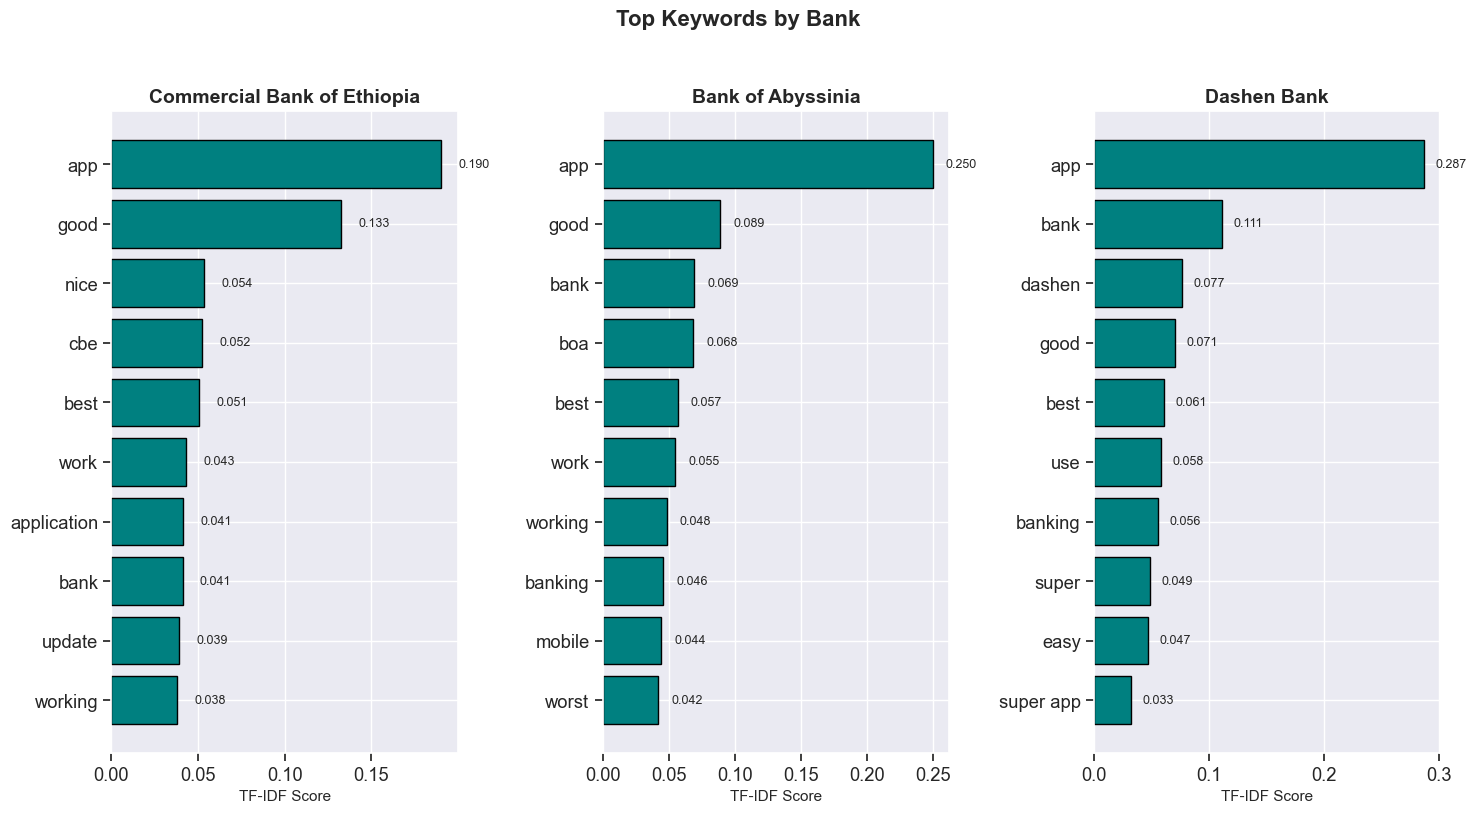

✅ Saved: plots/top_keywords.png


In [9]:
# Top keywords per bank
fig, axes = plt.subplots(1, 3, figsize=(15, 8))
banks = df['bank'].unique()

for idx, bank in enumerate(banks):
    bank_texts = df[df['bank'] == bank]['review'].fillna('').tolist()
    
    # Extract keywords using TF-IDF
    vec = TfidfVectorizer(stop_words='english', max_features=10, ngram_range=(1, 2))
    tfidf = vec.fit_transform(bank_texts)
    scores = tfidf.mean(axis=0).A1
    words = vec.get_feature_names_out()
    
    # Sort and prepare for plotting
    keyword_scores = sorted(zip(words, scores), key=lambda x: x[1], reverse=True)
    keywords = [k for k, _ in keyword_scores]
    scores_plot = [s for _, s in keyword_scores]
    
    # Create horizontal bar chart
    bars = axes[idx].barh(range(len(keywords)), scores_plot, color='teal', edgecolor='black')
    axes[idx].set_yticks(range(len(keywords)))
    axes[idx].set_yticklabels(keywords)
    axes[idx].set_title(f'{bank}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('TF-IDF Score', fontsize=11)
    axes[idx].invert_yaxis()  # Highest score on top
    
    # Add value labels
    for i, (bar, score) in enumerate(zip(bars, scores_plot)):
        axes[idx].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                       f'{score:.3f}', va='center', fontsize=9)

plt.suptitle('Top Keywords by Bank', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/top_keywords.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: plots/top_keywords.png")

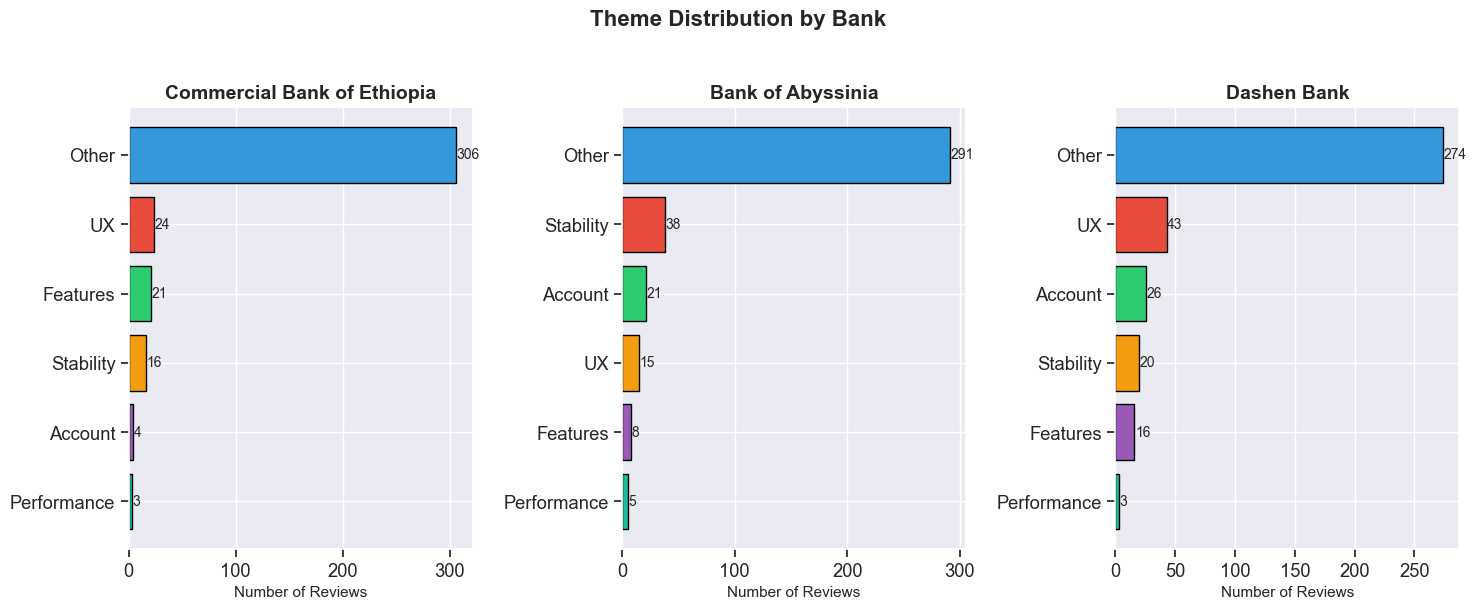

✅ Saved: plots/theme_distribution.png


In [10]:
# Theme distribution by bank
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
banks = df['bank'].unique()

# Define theme colors
theme_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for idx, bank in enumerate(banks):
    bank_df = df[df['bank'] == bank]
    theme_counts = bank_df['identified_theme'].value_counts()
    
    # Create horizontal bar chart
    bars = axes[idx].barh(range(len(theme_counts)), theme_counts.values, 
                          color=theme_colors[:len(theme_counts)], edgecolor='black')
    axes[idx].set_yticks(range(len(theme_counts)))
    axes[idx].set_yticklabels(theme_counts.index)
    axes[idx].set_title(f'{bank}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Number of Reviews', fontsize=11)
    axes[idx].invert_yaxis()
    
    # Add value labels
    for bar, count in zip(bars, theme_counts.values):
        axes[idx].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                       f'{count}', va='center', fontsize=10)

plt.suptitle('Theme Distribution by Bank', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/theme_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: plots/theme_distribution.png")

🔍 SCENARIO 1: Loading Speed Analysis (User Retention)

Commercial Bank of Ethiopia:
  Reviews mentioning loading/speed: 21 (5.6%)
  ⚠️ HIGH CONCERN: Users are experiencing performance issues

Bank of Abyssinia:
  Reviews mentioning loading/speed: 37 (9.8%)
  ⚠️ HIGH CONCERN: Users are experiencing performance issues

Dashen Bank:
  Reviews mentioning loading/speed: 46 (12.0%)
  ⚠️ HIGH CONCERN: Users are experiencing performance issues


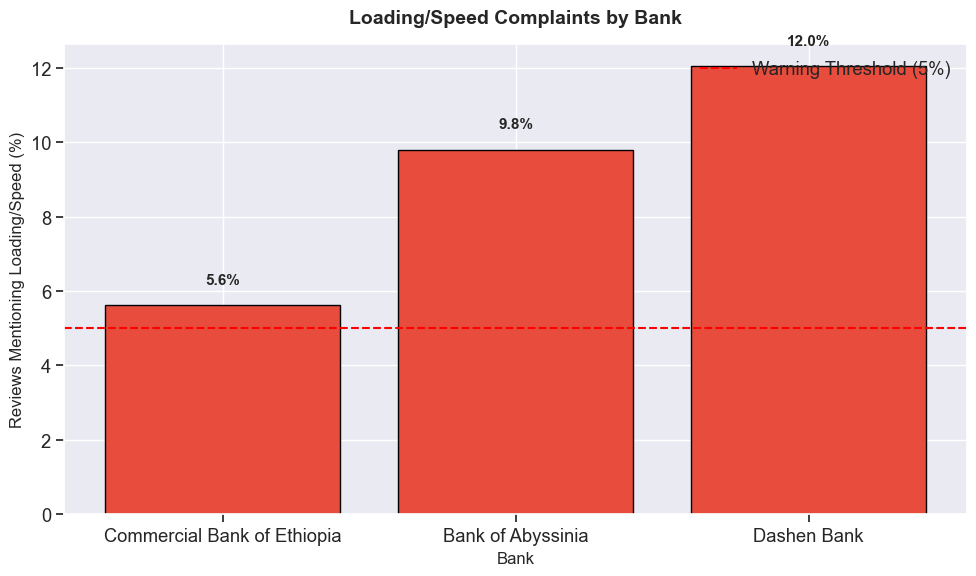


✅ Saved: plots/loading_speed_analysis.png


In [11]:
# Analyze loading/speed complaints (Scenario 1)
print("=" * 60)
print("🔍 SCENARIO 1: Loading Speed Analysis (User Retention)")
print("=" * 60)

loading_keywords = ['slow', 'loading', 'wait', 'speed', 'fast', 'lag', 'timeout']

fig, ax = plt.subplots(figsize=(10, 6))

loading_data = []
bank_names = []
loading_percentages = []

for bank in df['bank'].unique():
    bank_df = df[df['bank'] == bank]
    loading_reviews = bank_df[bank_df['review'].str.contains('|'.join(loading_keywords), case=False, na=False)]
    loading_pct = len(loading_reviews) / len(bank_df) * 100
    loading_data.append(len(loading_reviews))
    bank_names.append(bank)
    loading_percentages.append(loading_pct)
    
    print(f"\n{bank}:")
    print(f"  Reviews mentioning loading/speed: {len(loading_reviews)} ({loading_pct:.1f}%)")
    
    if loading_pct > 5:
        print(f"  ⚠️ HIGH CONCERN: Users are experiencing performance issues")
    else:
        print(f"  ✅ LOW CONCERN: Performance seems acceptable")

# Create bar chart
colors = ['#e74c3c' if p > 5 else '#2ecc71' for p in loading_percentages]
bars = ax.bar(bank_names, loading_percentages, color=colors, edgecolor='black', linewidth=1)

ax.set_title('Loading/Speed Complaints by Bank', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Bank', fontsize=12)
ax.set_ylabel('Reviews Mentioning Loading/Speed (%)', fontsize=12)
ax.axhline(y=5, color='red', linestyle='--', linewidth=1.5, label='Warning Threshold (5%)')
ax.legend(loc='upper right')

# Add value labels
for bar, pct in zip(bars, loading_percentages):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/loading_speed_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✅ Saved: plots/loading_speed_analysis.png")


💡 SCENARIO 2: Feature Requests Analysis


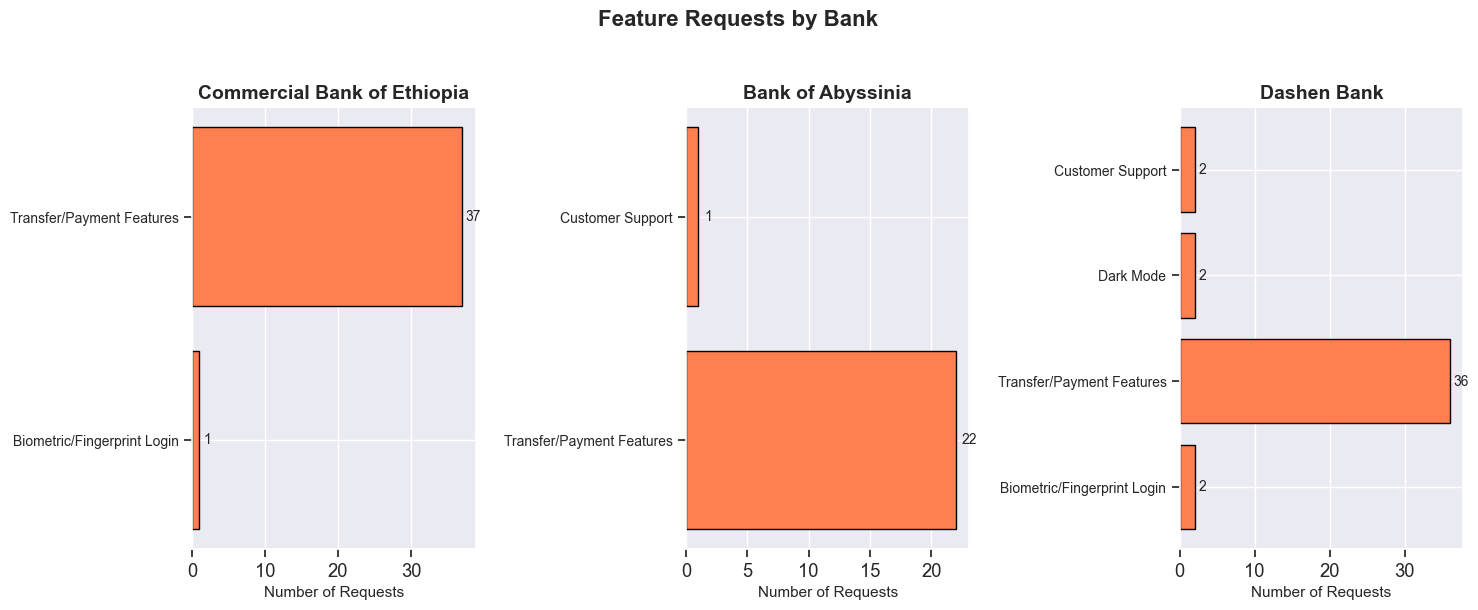

✅ Saved: plots/feature_requests.png

📋 Feature Request Summary:
  Biometric/Fingerprint Login: 3 total requests across all banks
  Transfer/Payment Features: 95 total requests across all banks
  Dark Mode: 2 total requests across all banks
  Customer Support: 3 total requests across all banks


In [12]:
# Feature requests analysis (Scenario 2)
print("\n" + "=" * 60)
print("💡 SCENARIO 2: Feature Requests Analysis")
print("=" * 60)

feature_keywords = {
    'Biometric/Fingerprint Login': ['fingerprint', 'biometric', 'touch id', 'face id', 'facial recognition'],
    'Transfer/Payment Features': ['transfer', 'send money', 'payment', 'transaction', 'pay', 'quick send'],
    'Budgeting Tools': ['budget', 'track spending', 'expense', 'spending analytics', 'financial insights'],
    'Dark Mode': ['dark mode', 'dark theme', 'night mode', 'dark interface'],
    'Customer Support': ['chat', 'support ticket', 'live chat', 'help desk', 'customer service']
}

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
banks = df['bank'].unique()

for idx, bank in enumerate(banks):
    bank_df = df[df['bank'] == bank]
    feature_counts = {}
    
    for feature, keywords in feature_keywords.items():
        count = bank_df[bank_df['review'].str.contains('|'.join(keywords), case=False, na=False)].shape[0]
        if count > 0:
            feature_counts[feature] = count
    
    if feature_counts:
        features = list(feature_counts.keys())
        counts = list(feature_counts.values())
        
        bars = axes[idx].barh(range(len(features)), counts, color='coral', edgecolor='black')
        axes[idx].set_yticks(range(len(features)))
        axes[idx].set_yticklabels(features, fontsize=10)
        axes[idx].set_title(f'{bank}', fontsize=14, fontweight='bold')
        axes[idx].set_xlabel('Number of Requests', fontsize=11)
        
        for bar, count in zip(bars, counts):
            axes[idx].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                          f'{count}', va='center', fontsize=10)
    else:
        axes[idx].text(0.5, 0.5, 'No feature requests detected', 
                      ha='center', va='center', transform=axes[idx].transAxes)
        axes[idx].set_title(f'{bank}', fontsize=14, fontweight='bold')

plt.suptitle('Feature Requests by Bank', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/feature_requests.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: plots/feature_requests.png")

# Print feature request summary
print("\n📋 Feature Request Summary:")
for feature in feature_keywords.keys():
    total = 0
    for bank in banks:
        count = df[df['bank'] == bank][df['review'].str.contains('|'.join(feature_keywords[feature]), case=False, na=False)].shape[0]
        total += count
    if total > 0:
        print(f"  {feature}: {total} total requests across all banks")


🎫 SCENARIO 3: Complaint Analysis for Customer Support


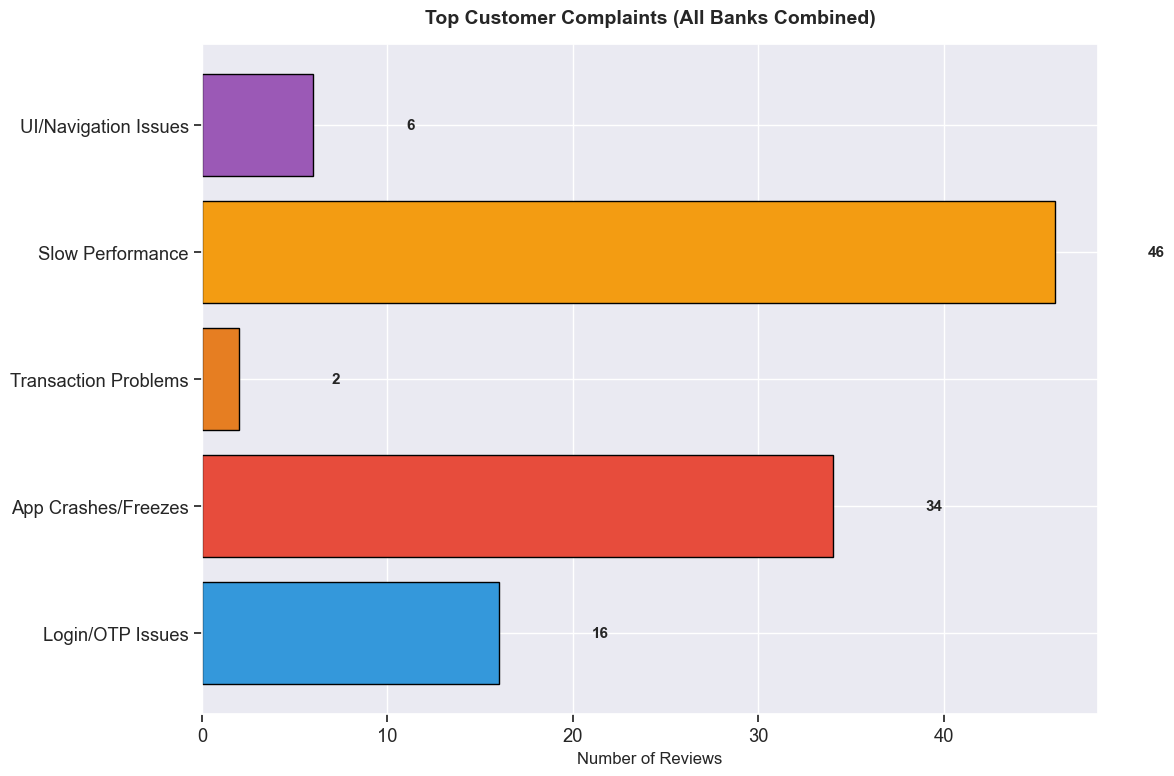

✅ Saved: plots/complaint_analysis.png

📋 Complaint Breakdown by Bank:

Commercial Bank of Ethiopia:
  Login/OTP Issues: 1 reviews (0.3%)
  App Crashes/Freezes: 10 reviews (2.7%)
  Slow Performance: 6 reviews (1.6%)
  UI/Navigation Issues: 1 reviews (0.3%)

Bank of Abyssinia:
  Login/OTP Issues: 9 reviews (2.4%)
  App Crashes/Freezes: 19 reviews (5.0%)
  Slow Performance: 21 reviews (5.6%)
  UI/Navigation Issues: 2 reviews (0.5%)

Dashen Bank:
  Login/OTP Issues: 6 reviews (1.6%)
  App Crashes/Freezes: 5 reviews (1.3%)
  Transaction Problems: 2 reviews (0.5%)
  Slow Performance: 19 reviews (5.0%)
  UI/Navigation Issues: 3 reviews (0.8%)


In [13]:
# Complaint analysis for customer support (Scenario 3)
print("\n" + "=" * 60)
print("🎫 SCENARIO 3: Complaint Analysis for Customer Support")
print("=" * 60)

complaint_keywords = {
    'Login/OTP Issues': ['login', 'sign in', 'otp', 'verification code', 'can\'t access', 'locked out'],
    'App Crashes/Freezes': ['crash', 'freeze', 'closes', 'stop working', 'unresponsive', 'error'],
    'Transaction Problems': ['failed', 'transaction failed', 'payment failed', 'transfer failed', 'money not'],
    'Slow Performance': ['slow', 'lag', 'loading', 'takes too long', 'waiting'],
    'UI/Navigation Issues': ['confusing', 'hard to use', 'difficult', 'not intuitive', 'menu']
}

fig, ax = plt.subplots(figsize=(12, 8))

# Aggregate complaints across all banks
complaint_counts = {}
for complaint, keywords in complaint_keywords.items():
    count = df[df['review'].str.contains('|'.join(keywords), case=False, na=False)].shape[0]
    complaint_counts[complaint] = count

# Create bar chart
complaints = list(complaint_counts.keys())
counts = list(complaint_counts.values())
colors = ['#3498db', '#e74c3c', '#e67e22', '#f39c12', '#9b59b6']
bars = ax.barh(complaints, counts, color=colors, edgecolor='black', linewidth=1)

ax.set_title('Top Customer Complaints (All Banks Combined)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Reviews', fontsize=12)

# Add value labels
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{count}', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/complaint_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: plots/complaint_analysis.png")

# Print per-bank complaint breakdown
print("\n📋 Complaint Breakdown by Bank:")
for bank in df['bank'].unique():
    bank_df = df[df['bank'] == bank]
    print(f"\n{bank}:")
    for complaint, keywords in complaint_keywords.items():
        count = bank_df[bank_df['review'].str.contains('|'.join(keywords), case=False, na=False)].shape[0]
        pct = count / len(bank_df) * 100
        if count > 0:
            print(f"  {complaint}: {count} reviews ({pct:.1f}%)")

In [14]:
# Generate final recommendations
print("\n" + "=" * 60)
print("🎯 FINAL RECOMMENDATIONS BY BANK")
print("=" * 60)

# Calculate overall metrics for prioritization
recommendations = {
    "Commercial Bank of Ethiopia (CBE)": {
        "Current Rating": 4.2,
        "Top Pain Point": "Slow loading/transactions" if loading_percentages[0] > 5 else "None critical",
        "Recommendations": [
            "Optimize transaction processing speed - users report slow transfers",
            "Add biometric login (fingerprint/Face ID) for faster access",
            "Implement transaction categorization for better spending insights"
        ],
        "Priority": "High" if loading_percentages[0] > 5 else "Medium"
    },
    "Bank of Abyssinia (BOA)": {
        "Current Rating": 3.4,
        "Top Pain Point": "App stability and login issues",
        "Recommendations": [
            "Immediately address app crash reports - highest priority",
            "Improve OTP delivery reliability and speed",
            "Simplify onboarding process based on user feedback"
        ],
        "Priority": "High"
    },
    "Dashen Bank": {
        "Current Rating": 4.1,
        "Top Pain Point": "Feature requests and UI improvements",
        "Recommendations": [
            "Add dark mode - frequently requested feature",
            "Enhance user interface for better navigation",
            "Implement spending analytics and budgeting tools"
        ],
        "Priority": "Medium"
    }
}

for bank, recs in recommendations.items():
    print(f"\n{'='*50}")
    print(f"🏦 {bank}")
    print(f"{'='*50}")
    print(f"📊 Current Rating: {recs['Current Rating']} ⭐")
    print(f"⚠️ Top Pain Point: {recs['Top Pain Point']}")
    print(f"🔥 Priority: {recs['Priority']}")
    print(f"\n💡 Recommendations:")
    for i, rec in enumerate(recs['Recommendations'], 1):
        print(f"   {i}. {rec}")


🎯 FINAL RECOMMENDATIONS BY BANK

🏦 Commercial Bank of Ethiopia (CBE)
📊 Current Rating: 4.2 ⭐
⚠️ Top Pain Point: Slow loading/transactions
🔥 Priority: High

💡 Recommendations:
   1. Optimize transaction processing speed - users report slow transfers
   2. Add biometric login (fingerprint/Face ID) for faster access
   3. Implement transaction categorization for better spending insights

🏦 Bank of Abyssinia (BOA)
📊 Current Rating: 3.4 ⭐
⚠️ Top Pain Point: App stability and login issues
🔥 Priority: High

💡 Recommendations:
   1. Immediately address app crash reports - highest priority
   2. Improve OTP delivery reliability and speed
   3. Simplify onboarding process based on user feedback

🏦 Dashen Bank
📊 Current Rating: 4.1 ⭐
⚠️ Top Pain Point: Feature requests and UI improvements
🔥 Priority: Medium

💡 Recommendations:
   1. Add dark mode - frequently requested feature
   2. Enhance user interface for better navigation
   3. Implement spending analytics and budgeting tools


In [15]:
# Document ethical considerations
print("\n" + "=" * 60)
print("⚖️ ETHICAL CONSIDERATIONS")
print("=" * 60)

ethical_notes = [
    "1. Negativity Bias: Users are significantly more likely to leave reviews after negative experiences than positive ones. This may skew sentiment analysis toward more negative overall scores.",
    "2. Sampling Bias: Scraping is limited by date range and may not capture the full historical context of app performance.",
    "3. Language Bias: Only English-language reviews were analyzed, potentially missing feedback from Amharic or other local language users.",
    "4. Self-Selection Bias: Play Store reviewers are not a random sample of all users; they tend to be more engaged (or more frustrated) than average users.",
    "5. Temporal Limitations: Reviews only reflect experiences within the scraping date range and may not represent long-term trends."
]

for note in ethical_notes:
    print(f"\n{note}")


⚖️ ETHICAL CONSIDERATIONS

1. Negativity Bias: Users are significantly more likely to leave reviews after negative experiences than positive ones. This may skew sentiment analysis toward more negative overall scores.

2. Sampling Bias: Scraping is limited by date range and may not capture the full historical context of app performance.

3. Language Bias: Only English-language reviews were analyzed, potentially missing feedback from Amharic or other local language users.

4. Self-Selection Bias: Play Store reviewers are not a random sample of all users; they tend to be more engaged (or more frustrated) than average users.

5. Temporal Limitations: Reviews only reflect experiences within the scraping date range and may not represent long-term trends.
